# Reading CSV files

CSV ("comma separated values") files are one of the most common ways to store
tables of data in biology and beyond. In this notebook we read one using only
the Python standard library — no extra packages — which shows you exactly what
is going on. (Later, in Lecture 5, we will use pandas to do this more
concisely.)

In [1]:
import matplotlib.pyplot as plt

CSV files are not perfectly standardized, but they are simple: each line is a row, and within a line the values are separated by commas. Here we open one and read its contents into a **dictionary** with one key per column and a list of values for each column.

For example, with `file.csv` like so:

```
column 1,column 2
1,2
3,4
```

we want to extract a dictionary like this:

```python
{'column 1': [1, 3], 'column 2': [2, 4]}
```

We will do this for the file `iris.csv`, which sits alongside this notebook.

In [4]:
fobj = open("iris.csv")

In [6]:
fobj = open("iris.csv")
for line_num, line in enumerate(fobj.readlines()):
    print(repr(line))
    if line_num > 5:
        break

'sepal_length,sepal_width,petal_length,petal_width,species\n'
'5.1,3.5,1.4,0.2,setosa\n'
'4.9,3.0,1.4,0.2,setosa\n'
'4.7,3.2,1.3,0.2,setosa\n'
'4.6,3.1,1.5,0.2,setosa\n'
'5.0,3.6,1.4,0.2,setosa\n'
'5.4,3.9,1.7,0.4,setosa\n'


In [7]:
fobj = open("iris.csv")
for line_num, line in enumerate(fobj.readlines()):
    line = line.strip()
    print(repr(line))
    if line_num > 5:
        break

'sepal_length,sepal_width,petal_length,petal_width,species'
'5.1,3.5,1.4,0.2,setosa'
'4.9,3.0,1.4,0.2,setosa'
'4.7,3.2,1.3,0.2,setosa'
'4.6,3.1,1.5,0.2,setosa'
'5.0,3.6,1.4,0.2,setosa'
'5.4,3.9,1.7,0.4,setosa'


In [8]:
fobj = open("iris.csv")
iris_dataset_from_csv= {}
for line_num, line in enumerate(fobj.readlines()):
    line = line.strip()
    entries = line.split(',')
    # print(entries)
    # if line_num > 5:
    #     break
    if line_num == 0:
        column_names = entries
        for column_name in column_names:
            iris_dataset_from_csv[column_name] = []
        continue
    # if we are here, we are line_num >= 1 and iris_dataset_from_csv is set up with columns and
    # column_names has our column names in the right order.
    for (column_name, entry) in zip(column_names, entries):
        if column_name != 'species':
            entry = float(entry)
        iris_dataset_from_csv[column_name].append(entry) 

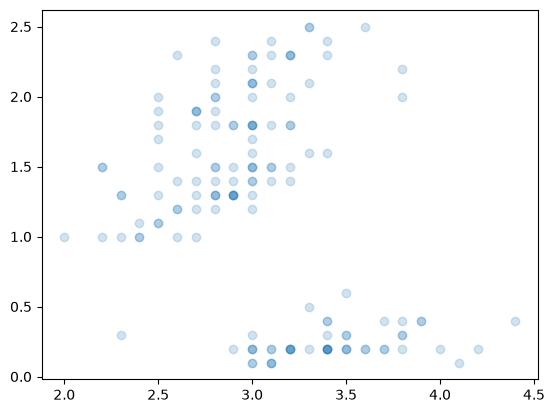

In [10]:
plt.plot(iris_dataset_from_csv['sepal_width'], iris_dataset_from_csv['petal_width'],'o', alpha=0.2);

# Using matplotlib from Python programs (not in Jupyter):

Open an interactive window:

```python
plt.show()
```

Save figure to file

```python
plt.savefig("plot_filename.png")
```

# Good programming habits

You now have enough Python to write real programs. A few habits will save you
(and your collaborators) a lot of time.

## Coding style

It is great if your code runs successfully! However, you are likely to want to run it again. (And even if not, it is good to practice "Doin' It Right".) Therefore, it is good to optimize it for readability and reuse. There is certainly a sense of style in software coding. It's good to develop your own sense of good style.

There is more one way to write correct code. (In fact, there are infinitely many ways.)

Depending on the programming language, and often depending on the project or environment, there are standard, "idiomatic" ways of doing things. You should prefer those - they make your code easier to read for others - and also yourself in the future.

It is useful to spend time refining code so that it looks simple and, ideally, *is* simple. Of course this is not always possible.

One stylistic rule that holds pretty much in every programming language is the principle "Don't Repeat Yourself" (DRY).  If you need to change something, ideally you will only need to change it in one place in your code. Another way of saying this is that there should only be a "single source of truth".

The python package "black" is commonly used linter for making code style changes to an idiomatic format.

### Style suggestions

- In general: simplify
- Remove irrelevant code (e.g. `plt.show;`)
- Remove irrelevant comments (e.g. `# YOUR CODE HERE`)

### Test small examples with `assert`

When you write a function, check it on a small example whose answer you already
know, using `assert` (as we did earlier in this lecture). This catches mistakes
immediately and documents what the function is supposed to do:

```python
def double(x):
    return 2 * x

assert double(4) == 8
assert double(0) == 0
```